# CIC-IDS 2017 Data Preprocessing, Feature Engineering & Visualization

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load Raw Data

In [7]:
RAW_DATA_PATH = 'data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
df = pd.read_csv(RAW_DATA_PATH, encoding='cp1252', low_memory=False)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.replace('\x96', '-').str.strip()

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):')
print(list(df.columns))
print(f'\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nData types:\n{df.dtypes.value_counts()}')
print(f'\nMissing values per column:\n{df.isna().sum().sort_values(ascending=False).head(20)}')

Shape: (170366, 79)
Columns (79):
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',

## 2. Data Cleaning

In [8]:
# Drop rows that are entirely NaN
df = df.dropna(how='all').reset_index(drop=True)
print(f'After dropping all-NaN rows: {df.shape}')

# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dropping duplicates: {df.shape}')

# Check remaining missing values
missing = df.isna().sum()
print(f'Total missing values: {missing.sum()}')
print(f'Columns with missing values:\n{missing[missing > 0]}')

After dropping all-NaN rows: (170366, 79)
After dropping duplicates: (164300, 79)
Total missing values: 19
Columns with missing values:
Flow Bytes/s    19
dtype: int64


In [10]:
print("Columns in the downloaded CICIDS file:")
print(list(df.columns))

METADATA_COLS = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']

missing_cols = [col for col in METADATA_COLS if col not in df.columns]

print("\nMetadata columns missing from the dataset:")
print(missing_cols)

Columns in the downloaded CICIDS file:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Co

In [11]:
LABEL_COL = 'Label'
numeric_cols = df.columns[df.columns != LABEL_COL]

# Convert all feature columns to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace inf/-inf with NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

df[numeric_cols] = df[numeric_cols].where(df[numeric_cols] >= 0)

print(f'NaNs after coercion and invalid handling: {df[numeric_cols].isna().sum().sum()}')

NaNs after coercion and invalid handling: 176482


In [12]:
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f'NaNs after median imputation: {df[numeric_cols].isna().sum().sum()}')

NaNs after median imputation: 0


## 3. Label Encoding

In [13]:
df['Label_binary'] = np.where(df[LABEL_COL] == 'BENIGN', 'BENIGN', 'ATTACK')
df['Label_encoded'] = (df['Label_binary'] == 'ATTACK').astype(int)

le = LabelEncoder()
df['Label_multiclass'] = le.fit_transform(df[LABEL_COL])

print('Multiclass label distribution:')
print(df[LABEL_COL].value_counts())
print('\nBinary label distribution:')
print(df['Label_binary'].value_counts())
print(f'\nEncoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Multiclass label distribution:
Label
BENIGN                          162157
Web Attack ï¿½ Brute Force        1470
Web Attack ï¿½ XSS                 652
Web Attack ï¿½ Sql Injection        21
Name: count, dtype: int64

Binary label distribution:
Label_binary
BENIGN    162157
ATTACK      2143
Name: count, dtype: int64

Encoded classes: {'BENIGN': 0, 'Web Attack ï¿½ Brute Force': 1, 'Web Attack ï¿½ Sql Injection': 2, 'Web Attack ï¿½ XSS': 3}


## 4. Feature Engineering

In [15]:
# ============================================
# 4. Create Common Features for Cross-Dataset Evaluation
# ============================================

common_features = pd.DataFrame(index=df.index)

# Convert CICIDS Flow Duration from microseconds to seconds
common_features['flow_duration'] = df['Flow Duration'] / 1_000_000

# Packet counts
common_features['fwd_packets'] = df['Total Fwd Packets']
common_features['bwd_packets'] = df['Total Backward Packets']

# Byte counts
common_features['fwd_bytes'] = df['Total Length of Fwd Packets']
common_features['bwd_bytes'] = df['Total Length of Bwd Packets']

# Forward / backward packet ratio
common_features['fwd_to_bwd_pkt_ratio'] = (
    df['Total Fwd Packets'] /
    (df['Total Backward Packets'] + 1)
)

# Forward / backward byte ratio
common_features['fwd_to_bwd_byte_ratio'] = (
    df['Total Length of Fwd Packets'] /
    (df['Total Length of Bwd Packets'] + 1)
)

# Total packets and bytes
total_packets = (
    df['Total Fwd Packets'] +
    df['Total Backward Packets']
)

total_bytes = (
    df['Total Length of Fwd Packets'] +
    df['Total Length of Bwd Packets']
)

# Bytes per packet
common_features['bytes_per_packet'] = (
    total_bytes / (total_packets + 1)
)

# Packets per second
common_features['packets_per_second'] = (
    total_packets /
    (common_features['flow_duration'] + 1e-6)
)

# Binary label
common_features['label'] = df['Label_encoded']

print("Common feature shape:", common_features.shape)

print("\nCommon features:")
print(common_features.columns.tolist())

print("\nFirst 5 rows:")
display(common_features.head())

Common feature shape: (164300, 10)

Common features:
['flow_duration', 'fwd_packets', 'bwd_packets', 'fwd_bytes', 'bwd_bytes', 'fwd_to_bwd_pkt_ratio', 'fwd_to_bwd_byte_ratio', 'bytes_per_packet', 'packets_per_second', 'label']

First 5 rows:


,flow_duration,fwd_packets,bwd_packets,fwd_bytes,bwd_bytes,fwd_to_bwd_pkt_ratio,fwd_to_bwd_byte_ratio,bytes_per_packet,packets_per_second,label
0,113.095465,48,24,9668,10012,1.920000,0.965545,269.589041,0.636630,0
1,113.473706,68,40,11364,12718,1.658537,0.893466,220.935780,0.951762,0
2,119.945515,150,0,0,0,150.000000,0.000000,0.000000,1.250568,0
3,60.261928,9,7,2330,4221,1.125000,0.551871,385.352941,0.265508,0
4,0.000269,2,2,102,322,0.666667,0.315789,84.800000,14814.814815,0


In [17]:
# Clean common features

feature_cols = [
    'flow_duration',
    'fwd_packets',
    'bwd_packets',
    'fwd_bytes',
    'bwd_bytes',
    'fwd_to_bwd_pkt_ratio',
    'fwd_to_bwd_byte_ratio',
    'bytes_per_packet',
    'packets_per_second'
]

# Replace infinite values with NaN
common_features[feature_cols] = common_features[feature_cols].replace(
    [np.inf, -np.inf], np.nan
)

# Check missing values
print("Missing values:")
print(common_features[feature_cols].isna().sum())

print("\nCommon feature shape:")
print(common_features.shape)

Missing values:
flow_duration            0
fwd_packets              0
bwd_packets              0
fwd_bytes                0
bwd_bytes                0
fwd_to_bwd_pkt_ratio     0
fwd_to_bwd_byte_ratio    0
bytes_per_packet         0
packets_per_second       0
dtype: int64

Common feature shape:
(164300, 10)


In [18]:
from sklearn.model_selection import train_test_split

# Split features and target
X = common_features[feature_cols]
y = common_features['label']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training features: (131440, 9)
Testing features: (32860, 9)
Training labels: (131440,)
Testing labels: (32860,)

Training label distribution:
label
0    129726
1      1714
Name: count, dtype: int64

Testing label distribution:
label
0    32431
1      429
Name: count, dtype: int64


In [19]:
from sklearn.impute import SimpleImputer

# Create median imputer
imputer = SimpleImputer(strategy='median')

# Fit ONLY on training data
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

# Apply the fitted imputer to test data
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Training shape:", X_train_imputed.shape)
print("Testing shape:", X_test_imputed.shape)

print("\nMissing values in training:")
print(X_train_imputed.isna().sum().sum())

print("\nMissing values in testing:")
print(X_test_imputed.isna().sum().sum())

Training shape: (131440, 9)
Testing shape: (32860, 9)

Missing values in training:
0

Missing values in testing:
0


In [20]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imputed),
    columns=feature_cols,
    index=X_train_imputed.index
)

# Apply the fitted scaler to test data
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imputed),
    columns=feature_cols,
    index=X_test_imputed.index
)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print("\nTraining means after scaling:")
print(X_train_scaled.mean().round(4))

print("\nTraining standard deviations after scaling:")
print(X_train_scaled.std().round(4))

Training shape: (131440, 9)
Testing shape: (32860, 9)

Training means after scaling:
flow_duration            0.0
fwd_packets             -0.0
bwd_packets             -0.0
fwd_bytes                0.0
bwd_bytes                0.0
fwd_to_bwd_pkt_ratio    -0.0
fwd_to_bwd_byte_ratio    0.0
bytes_per_packet         0.0
packets_per_second      -0.0
dtype: float64

Training standard deviations after scaling:
flow_duration            1.0
fwd_packets              1.0
bwd_packets              1.0
fwd_bytes                1.0
bwd_bytes                1.0
fwd_to_bwd_pkt_ratio     1.0
fwd_to_bwd_byte_ratio    1.0
bytes_per_packet         1.0
packets_per_second       1.0
dtype: float64


In [21]:
# Final validation

print("=== FINAL VALIDATION ===")

print("\n1. Feature columns:")
print(X_train_scaled.columns.tolist())

print("\n2. Number of features:")
print(len(X_train_scaled.columns))

print("\n3. Shapes:")
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n4. Missing values:")
print("Train:", X_train_scaled.isna().sum().sum())
print("Test :", X_test_scaled.isna().sum().sum())

print("\n5. Infinite values:")
print("Train:", np.isinf(X_train_scaled.to_numpy()).sum())
print("Test :", np.isinf(X_test_scaled.to_numpy()).sum())

print("\n6. Labels:")
print("Train:", sorted(y_train.unique()))
print("Test :", sorted(y_test.unique()))

=== FINAL VALIDATION ===

1. Feature columns:
['flow_duration', 'fwd_packets', 'bwd_packets', 'fwd_bytes', 'bwd_bytes', 'fwd_to_bwd_pkt_ratio', 'fwd_to_bwd_byte_ratio', 'bytes_per_packet', 'packets_per_second']

2. Number of features:
9

3. Shapes:
X_train: (131440, 9)
X_test : (32860, 9)
y_train: (131440,)
y_test : (32860,)

4. Missing values:
Train: 0
Test : 0

5. Infinite values:
Train: 0
Test : 0

6. Labels:
Train: [0, 1]
Test : [0, 1]


In [22]:
import os
import joblib

# Create required directories
os.makedirs("data/preprocessed/aligned", exist_ok=True)
os.makedirs("data/preprocessed/artifacts", exist_ok=True)

# Add labels back to the scaled feature data
cicids_train_aligned = X_train_scaled.copy()
cicids_train_aligned["label"] = y_train.values

cicids_test_aligned = X_test_scaled.copy()
cicids_test_aligned["label"] = y_test.values

# Save aligned datasets
cicids_train_path = "data/preprocessed/aligned/CICIDS_train_aligned.csv"
cicids_test_path = "data/preprocessed/aligned/CICIDS_test_aligned.csv"

cicids_train_aligned.to_csv(cicids_train_path, index=False)
cicids_test_aligned.to_csv(cicids_test_path, index=False)

# Save preprocessing objects
joblib.dump(imputer, "data/preprocessed/artifacts/CICIDS_imputer.joblib")
joblib.dump(scaler, "data/preprocessed/artifacts/CICIDS_scaler.joblib")

# Save feature list
joblib.dump(feature_cols, "data/preprocessed/artifacts/common_feature_list.joblib")

print("CICIDS aligned data saved successfully!")
print(cicids_train_path)
print(cicids_test_path)

CICIDS aligned data saved successfully!
data/preprocessed/aligned/CICIDS_train_aligned.csv
data/preprocessed/aligned/CICIDS_test_aligned.csv


## 5. Visualizations

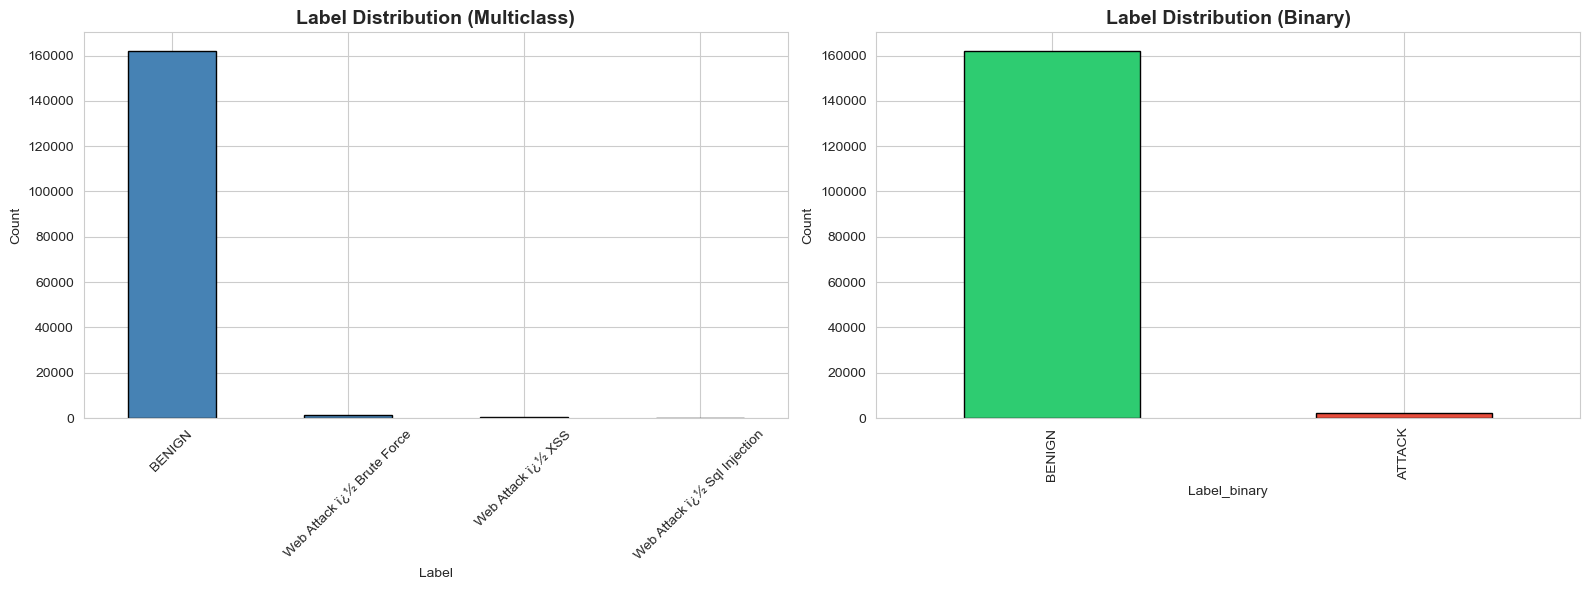

Saved: results/label_distribution.png


In [24]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Multiclass
df[LABEL_COL].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Label Distribution (Multiclass)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Binary
df['Label_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Label Distribution (Binary)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/label_distribution.png')

C:\Users\Akshita\AppData\Local\Temp\ipykernel_28852\1697823124.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=attack_df, x=feat, ax=ax, label='ATTACK', color='red', fill=True, alpha=0.3)


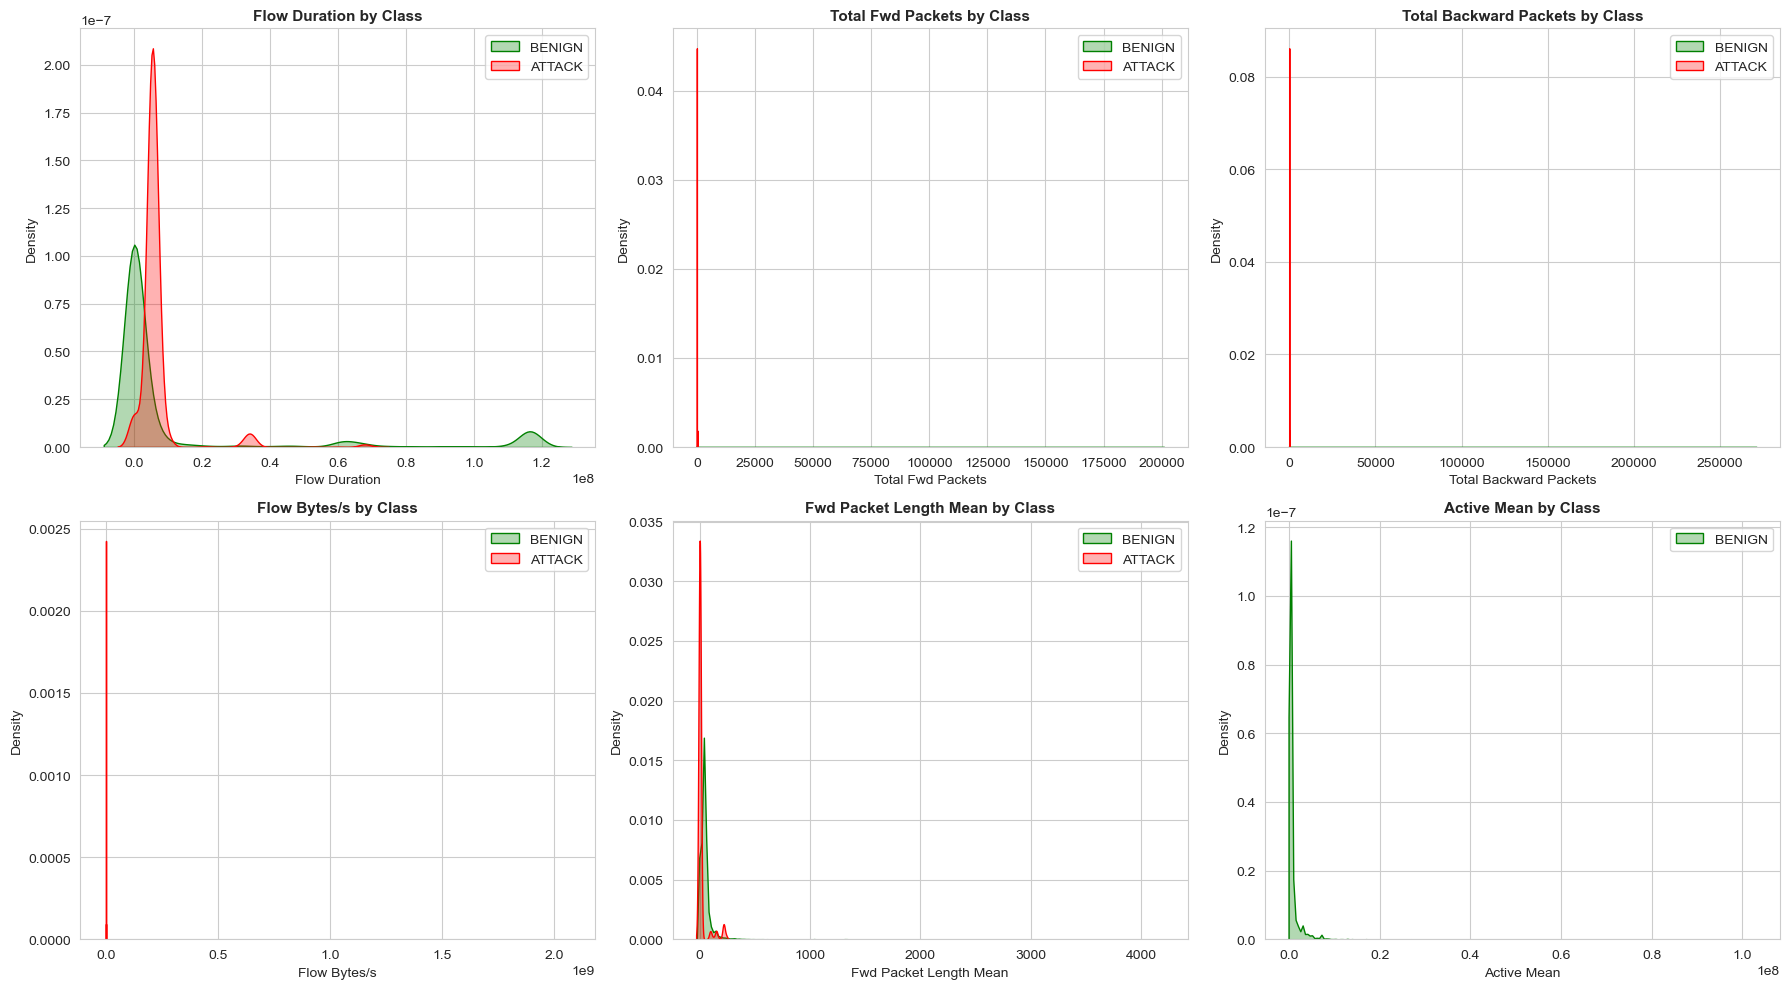

Saved: results/feature_distributions.png


In [25]:
# Distribution of key features by attack type
attack_df = df[df[LABEL_COL] != 'BENIGN']
benign_df = df[df[LABEL_COL] == 'BENIGN']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                    'Flow Bytes/s', 'Fwd Packet Length Mean', 'Active Mean']

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    sns.kdeplot(data=benign_df, x=feat, ax=ax, label='BENIGN', color='green', fill=True, alpha=0.3)
    sns.kdeplot(data=attack_df, x=feat, ax=ax, label='ATTACK', color='red', fill=True, alpha=0.3)
    ax.set_title(f'{feat} by Class', fontsize=11, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/feature_distributions.png')

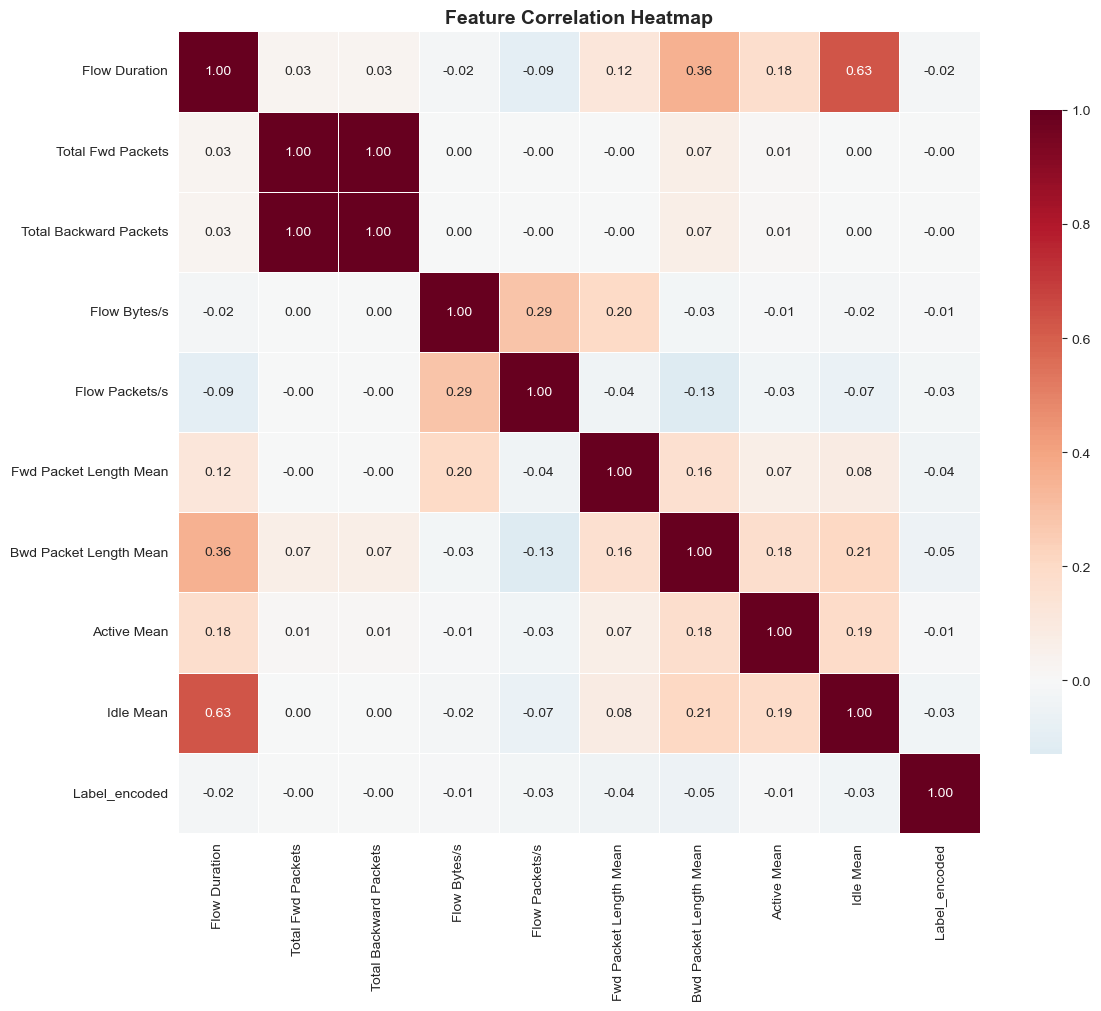

Saved: results/correlation_heatmap.png


In [26]:
# Correlation heatmap for key features
corr_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
                 'Bwd Packet Length Mean', 'Active Mean', 'Idle Mean',
                 'Label_encoded']
corr_df = df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/correlation_heatmap.png')

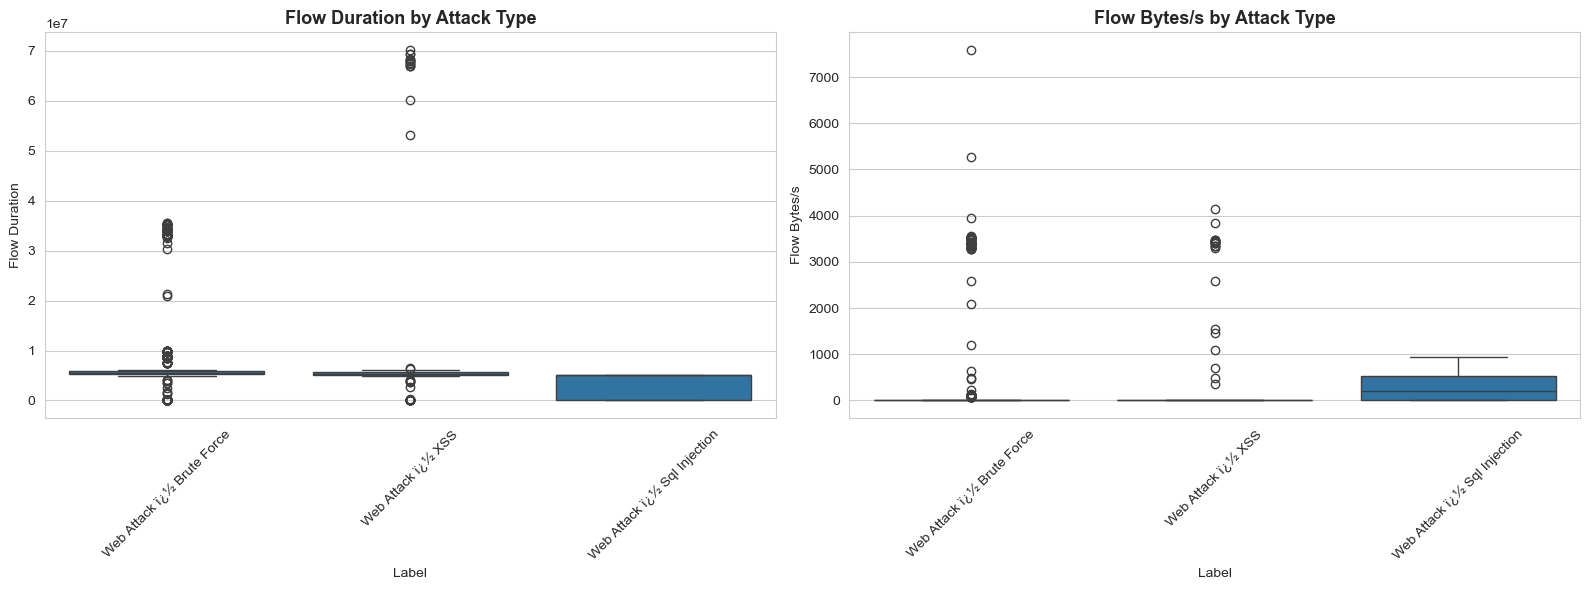

Saved: results/attack_comparison.png


In [27]:
# Compare attack types on key features
attack_types = df[df[LABEL_COL] != 'BENIGN']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Flow Duration by attack type
sns.boxplot(data=attack_types, x=LABEL_COL, y='Flow Duration', ax=axes[0])
axes[0].set_title('Flow Duration by Attack Type', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Box plot: Flow Bytes/s by attack type
sns.boxplot(data=attack_types, x=LABEL_COL, y='Flow Bytes/s', ax=axes[1])
axes[1].set_title('Flow Bytes/s by Attack Type', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/attack_comparison.png')

In [30]:
# ============================================================
# 9. Save Aligned Preprocessed Data
# ============================================================

import os

OUTPUT_DIR = 'data/preprocessed/aligned'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Combine scaled features with binary labels
train_output = X_train_scaled.copy()
train_output['label'] = y_train.values

test_output = X_test_scaled.copy()
test_output['label'] = y_test.values

# Save aligned datasets
train_path = os.path.join(
    OUTPUT_DIR,
    'CICIDS_train_aligned.csv'
)

test_path = os.path.join(
    OUTPUT_DIR,
    'CICIDS_test_aligned.csv'
)

train_output.to_csv(train_path, index=False)
test_output.to_csv(test_path, index=False)

print("Training data saved:")
print(train_path)

print("\nTesting data saved:")
print(test_path)

print("\nFinal training shape:", train_output.shape)
print("Final testing shape:", test_output.shape)

print("\nFeatures:")
print(X_train_scaled.columns.tolist())

print("\nBinary label distribution:")
print(train_output['label'].value_counts())

print("\nRemaining NaNs:")
print("Train:", train_output.isna().sum().sum())
print("Test:", test_output.isna().sum().sum())

Training data saved:
data/preprocessed/aligned\CICIDS_train_aligned.csv

Testing data saved:
data/preprocessed/aligned\CICIDS_test_aligned.csv

Final training shape: (131440, 10)
Final testing shape: (32860, 10)

Features:
['flow_duration', 'fwd_packets', 'bwd_packets', 'fwd_bytes', 'bwd_bytes', 'fwd_to_bwd_pkt_ratio', 'fwd_to_bwd_byte_ratio', 'bytes_per_packet', 'packets_per_second']

Binary label distribution:
label
0    129726
1      1714
Name: count, dtype: int64

Remaining NaNs:
Train: 0
Test: 0


## Summary

The CICIDS2017 preprocessing pipeline:

1. Loads the CICIDS2017 dataset.
2. Cleans missing, infinite, and invalid values.
3. Removes identifier and metadata columns such as Flow ID, Source IP, Destination IP, and Timestamp.
4. Creates binary labels (Normal/Benign = 0, Attack = 1).
5. Creates 9 common traffic features shared with UNSW-NB15.
6. Splits the data into training and testing sets before imputation and scaling.
7. Uses training data statistics for missing-value imputation.
8. Scales the aligned features using training data only.
9. Validates that both datasets contain the same ordered, numeric, finite 9 features and binary labels.
10. Saves the aligned CICIDS2017 training and testing datasets for the MLP, SHAP, and LIME stages.